# TransitionRx — Medication Complexity & Care-Transition Readmission Risk

### Project question
> For a generic hospital facing CMS Hospital Readmissions Reduction Program (HRRP) penalties, can discharge-level data already on hand — medication count, how much the regimen changed, and how thin the care transition was — flag which diabetes patients are at elevated risk of a preventable 30-day readmission?

### Notebook contents
1. Setup & data load
2. Cohort construction (exclusions, de-duplication, target definition)
3. EDA
4. Regimen-change / polypharmacy score from the 23 drug columns
5. Feature engineering (medication bands, prior-utilization bands, age bands, comorbidity counts)
6. Baseline XGBoost model
7. **Fine-tuning** — randomized hyperparameter search
8. Evaluation — ROC-AUC, PR-AUC, recall/precision/F1, calibration, confusion matrix
9. **Capacity-constrained threshold selection** (the actual business decision)
10. Explainability — feature importance & SHAP
11. Patient-level flag cards for pharmacists
12. Business value estimate & model export

## 1. Setup & data load

In [9]:
from google.colab import files
uploaded = files.upload()  # pick diabetic_data.csv and IDS_mapping.csv

Saving diabetic_data.csv to diabetic_data.csv
Saving IDS_mapping.csv to IDS_mapping.csv


In [10]:
!pip install xgboost shap --quiet

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_PATH = "diabetic_data.csv"      # adjust if needed
MAP_PATH  = "IDS_mapping.csv"

df_raw = pd.read_csv(DATA_PATH, na_values=["?"], low_memory=False)
print("Raw shape:", df_raw.shape)
df_raw.head(3)

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [12]:
# The 23 diabetes medication columns
DRUG_COLS = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride','acetohexamide',
    'glipizide','glyburide','tolbutamide','pioglitazone','rosiglitazone','acarbose','miglitol',
    'troglitazone','tolazamide','examide','citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]
print(len(DRUG_COLS), "drug columns")

# Missingness overview
miss = df_raw.isna().mean().sort_values(ascending=False)
print("\nColumns with missing values:")
print((miss[miss > 0] * 100).round(1).astype(str) + "%")

23 drug columns

Columns with missing values:
weight               96.9%
max_glu_serum        94.7%
A1Cresult            83.3%
medical_specialty    49.1%
payer_code           39.6%
race                  2.2%
diag_3                1.4%
diag_2                0.4%
diag_1                0.0%
dtype: object


## 2. Cohort construction

Three decisions that materially affect the result, each with a clinical/business rationale:

| Decision | Rationale |
|---|---|
| Drop expired & hospice discharges (IDs 11, 13, 14, 19, 20, 21) | These patients **cannot** be readmitted. Leaving them in dilutes the negative class with structural zeros. |
| Keep only the **first** encounter per patient | Rows are encounters, not patients. Multiple encounters per patient leak outcome information across the train/test split. |
| Target = `readmitted == '<30'` | The HRRP penalty window. `>30` is folded into the negative class because it's outside the decision's scope. |

In [13]:
EXPIRED_HOSPICE = [11, 13, 14, 19, 20, 21]

df = df_raw[~df_raw["discharge_disposition_id"].isin(EXPIRED_HOSPICE)].copy()
print(f"After removing expired/hospice: {df.shape[0]:,} rows")

df = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
print(f"After keeping first encounter per patient: {df.shape[0]:,} rows")

df["target"] = (df["readmitted"] == "<30").astype(int)

print(f"\n30-day readmission rate: {df['target'].mean():.2%}")
print(df["target"].value_counts().rename({0: "Not readmitted <30d", 1: "Readmitted <30d"}))

After removing expired/hospice: 99,343 rows
After keeping first encounter per patient: 69,990 rows

30-day readmission rate: 8.98%
target
Not readmitted <30d    63705
Readmitted <30d         6285
Name: count, dtype: int64


## 3. Exploratory data analysis

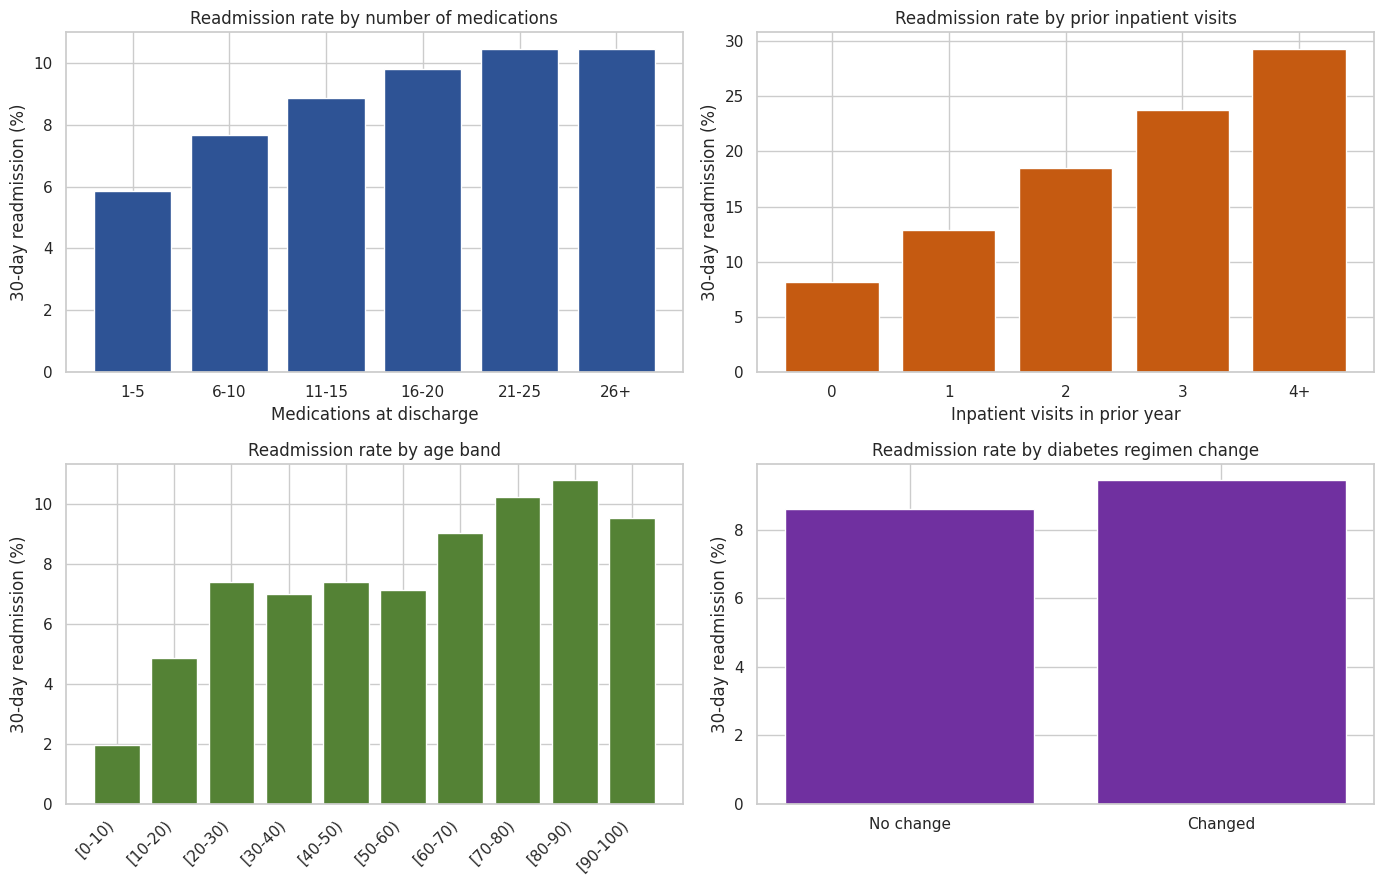

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Readmission by medication count
med_bins = pd.cut(df["num_medications"], [0, 5, 10, 15, 20, 25, 100],
                  labels=["1-5", "6-10", "11-15", "16-20", "21-25", "26+"])
med_rate = df.groupby(med_bins, observed=True)["target"].agg(["mean", "size"])
axes[0, 0].bar(med_rate.index.astype(str), med_rate["mean"] * 100, color="#2E5395")
axes[0, 0].set_title("Readmission rate by number of medications")
axes[0, 0].set_ylabel("30-day readmission (%)")
axes[0, 0].set_xlabel("Medications at discharge")

# Readmission by prior inpatient visits
inp_bins = pd.cut(df["number_inpatient"], [-1, 0, 1, 2, 3, 100],
                  labels=["0", "1", "2", "3", "4+"])
inp_rate = df.groupby(inp_bins, observed=True)["target"].mean()
axes[0, 1].bar(inp_rate.index.astype(str), inp_rate * 100, color="#C55A11")
axes[0, 1].set_title("Readmission rate by prior inpatient visits")
axes[0, 1].set_ylabel("30-day readmission (%)")
axes[0, 1].set_xlabel("Inpatient visits in prior year")

# Readmission by age
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']
age_rate = df.groupby("age", observed=True)["target"].mean().reindex(age_order)
axes[1, 0].bar(range(len(age_rate)), age_rate * 100, color="#548235")
axes[1, 0].set_xticks(range(len(age_rate)))
axes[1, 0].set_xticklabels(age_order, rotation=45, ha="right")
axes[1, 0].set_title("Readmission rate by age band")
axes[1, 0].set_ylabel("30-day readmission (%)")

# Readmission by regimen change flag
chg_rate = df.groupby("change", observed=True)["target"].mean()
axes[1, 1].bar(["No change", "Changed"], chg_rate.reindex(["No", "Ch"]) * 100, color="#7030A0")
axes[1, 1].set_title("Readmission rate by diabetes regimen change")
axes[1, 1].set_ylabel("30-day readmission (%)")

plt.tight_layout()
plt.show()

In [15]:
# How often is each drug actually touched?
drug_activity = pd.DataFrame({
    "prescribed": (df[DRUG_COLS] != "No").sum(),
    "dose_up":    (df[DRUG_COLS] == "Up").sum(),
    "dose_down":  (df[DRUG_COLS] == "Down").sum(),
    "steady":     (df[DRUG_COLS] == "Steady").sum(),
}).sort_values("prescribed", ascending=False)
drug_activity["pct_of_cohort"] = (drug_activity["prescribed"] / len(df) * 100).round(1)
drug_activity.head(12)

,prescribed,dose_up,dose_down,steady,pct_of_cohort
insulin,35722,6777,7324,21621,51.0
metformin,14905,834,435,13636,21.3
glipizide,9010,573,371,8066,12.9
glyburide,7776,613,418,6745,11.1
pioglitazone,5266,178,81,5007,7.5
rosiglitazone,4661,132,74,4455,6.7
glimepiride,3698,230,136,3332,5.3
repaglinide,917,71,28,818,1.3
glyburide-metformin,496,7,4,485,0.7
nateglinide,491,16,8,467,0.7


## 4. Regimen-change / polypharmacy score

Each drug column takes `No` / `Steady` / `Up` / `Down`. We collapse the 23 columns into interpretable measures:

- **`n_diabetes_drugs`** — how many diabetes agents the patient is on (polypharmacy burden)
- **`n_drug_up` / `n_drug_down`** — dose escalations / de-escalations
- **`regimen_change_score`** — total dose adjustments (`Up` + `Down`) = *regimen churn*
- **`regimen_churn_ratio`** — share of the patient's regimen that was altered this stay
- **`complexity_index`** — combined burden + churn, the single headline number for a pharmacist

In [16]:
df["n_diabetes_drugs"] = (df[DRUG_COLS] != "No").sum(axis=1)
df["n_drug_up"]         = (df[DRUG_COLS] == "Up").sum(axis=1)
df["n_drug_down"]       = (df[DRUG_COLS] == "Down").sum(axis=1)
df["n_drug_steady"]     = (df[DRUG_COLS] == "Steady").sum(axis=1)

df["regimen_change_score"] = df["n_drug_up"] + df["n_drug_down"]
df["regimen_churn_ratio"]  = (df["regimen_change_score"] /
                              df["n_diabetes_drugs"].replace(0, np.nan)).fillna(0)

# Headline complexity index: polypharmacy burden + weighted churn
df["complexity_index"] = df["n_diabetes_drugs"] + 2 * df["regimen_change_score"]

df[["n_diabetes_drugs", "n_drug_up", "n_drug_down",
    "regimen_change_score", "regimen_churn_ratio", "complexity_index"]].describe().round(2)

,n_diabetes_drugs,n_drug_up,n_drug_down,regimen_change_score,regimen_churn_ratio,complexity_index
count,69990.00,69990.00,69990.00,69990.00,69990.00,69990.00
mean,1.19,0.13,0.13,0.26,0.19,1.71
std,0.94,0.36,0.34,0.48,0.36,1.54
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,0.00,1.00
50%,1.00,0.00,0.00,0.00,0.00,1.00
75%,2.00,0.00,0.00,0.00,0.00,3.00
max,6.00,3.00,3.00,4.00,1.00,13.00


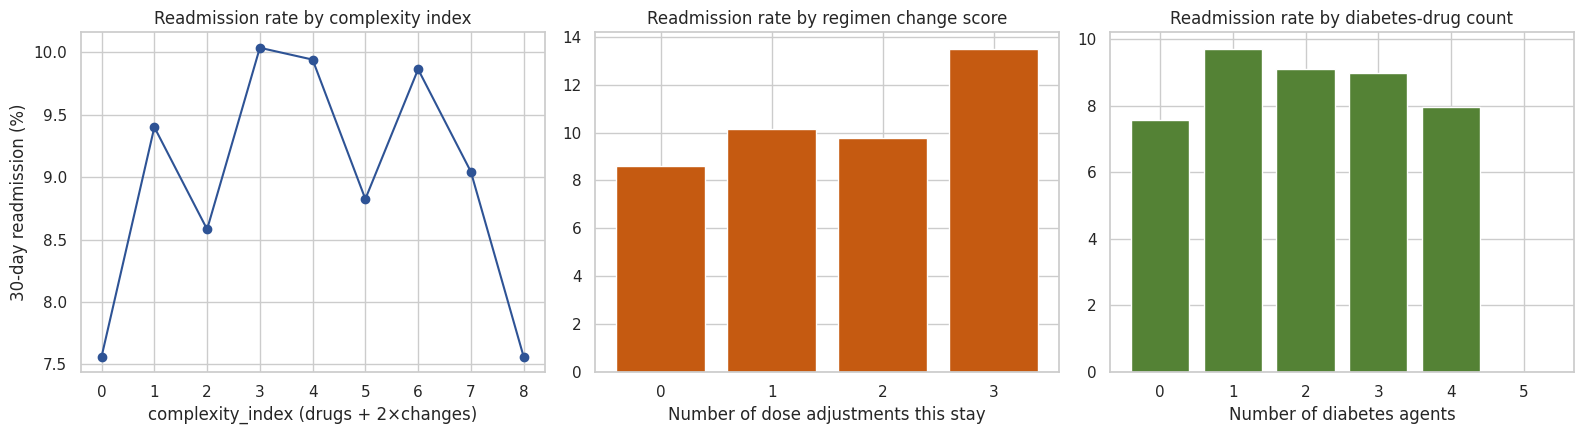

Readmission rate, no dose changes vs. any dose change:
regimen_change_score
False    0.0860
True     0.1013
Name: target, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

comp = df.groupby("complexity_index", observed=True)["target"].agg(["mean", "size"])
comp = comp[comp["size"] >= 100]
axes[0].plot(comp.index, comp["mean"] * 100, marker="o", color="#2E5395")
axes[0].set_title("Readmission rate by complexity index")
axes[0].set_xlabel("complexity_index (drugs + 2×changes)")
axes[0].set_ylabel("30-day readmission (%)")

chg = df.groupby("regimen_change_score", observed=True)["target"].agg(["mean", "size"])
chg = chg[chg["size"] >= 50]
axes[1].bar(chg.index.astype(str), chg["mean"] * 100, color="#C55A11")
axes[1].set_title("Readmission rate by regimen change score")
axes[1].set_xlabel("Number of dose adjustments this stay")

poly = df.groupby("n_diabetes_drugs", observed=True)["target"].agg(["mean", "size"])
poly = poly[poly["size"] >= 50]
axes[2].bar(poly.index.astype(str), poly["mean"] * 100, color="#548235")
axes[2].set_title("Readmission rate by diabetes-drug count")
axes[2].set_xlabel("Number of diabetes agents")

plt.tight_layout()
plt.show()

print("Readmission rate, no dose changes vs. any dose change:")
print(df.groupby(df["regimen_change_score"] > 0)["target"].mean().round(4))

## 5. Feature engineering

In [18]:
# --- Age band -> ordinal ---
AGE_ORDER = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']
df["age_ord"] = df["age"].map({v: i for i, v in enumerate(AGE_ORDER)})

# --- Medication-count bands ---
df["med_count_band"] = pd.cut(df["num_medications"], [-1, 5, 10, 15, 20, 500],
                              labels=[0, 1, 2, 3, 4]).astype(int)

# --- Prior-utilization bands (care-transition history) ---
df["prior_visits_total"]   = (df["number_outpatient"] + df["number_emergency"]
                              + df["number_inpatient"])
df["prior_inpatient_band"] = pd.cut(df["number_inpatient"], [-1, 0, 1, 3, 500],
                                    labels=[0, 1, 2, 3]).astype(int)
df["prior_emergency_band"] = pd.cut(df["number_emergency"], [-1, 0, 1, 3, 500],
                                    labels=[0, 1, 2, 3]).astype(int)
df["frequent_flyer"]       = (df["number_inpatient"] >= 2).astype(int)

# --- Comorbidity grouping from ICD-9 diagnosis codes ---
def diag_category(code):
    if pd.isna(code):
        return "missing"
    s = str(code)
    if s.startswith(("V", "E")):
        return "other"
    try:
        v = float(s)
    except ValueError:
        return "other"
    if 390 <= v <= 459 or v == 785:  return "circulatory"
    if 460 <= v <= 519 or v == 786:  return "respiratory"
    if 520 <= v <= 579 or v == 787:  return "digestive"
    if int(v) == 250:                return "diabetes"
    if 800 <= v <= 999:              return "injury"
    if 710 <= v <= 739:              return "musculoskeletal"
    if 580 <= v <= 629 or v == 788:  return "genitourinary"
    if 140 <= v <= 239:              return "neoplasms"
    return "other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[col + "_cat"] = df[col].apply(diag_category)

DIAG_CATS = df[["diag_1_cat", "diag_2_cat", "diag_3_cat"]]
df["n_circulatory"]   = (DIAG_CATS == "circulatory").sum(axis=1)
df["n_diabetes_diag"] = (DIAG_CATS == "diabetes").sum(axis=1)
df["n_respiratory"]   = (DIAG_CATS == "respiratory").sum(axis=1)
df["n_distinct_diag_cats"] = DIAG_CATS.nunique(axis=1)

# --- Care-transition quality proxies ---
df["discharged_home"]       = df["discharge_disposition_id"].isin([1, 6, 8]).astype(int)
df["transferred_facility"]  = df["discharge_disposition_id"].isin(
    [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]).astype(int)
df["home_no_services"]      = (df["discharge_disposition_id"] == 1).astype(int)
df["emergency_admission"]   = (df["admission_type_id"] == 1).astype(int)
df["short_stay"]            = (df["time_in_hospital"] <= 2).astype(int)

# --- Monitoring / med flags ---
df["A1C_measured"]     = df["A1Cresult"].notna().astype(int)
df["glu_measured"]     = df["max_glu_serum"].notna().astype(int)
df["change_flag"]      = (df["change"] == "Ch").astype(int)
df["diabetesMed_flag"] = (df["diabetesMed"] == "Yes").astype(int)
df["insulin_active"]   = (df["insulin"] != "No").astype(int)
df["insulin_changed"]  = df["insulin"].isin(["Up", "Down"]).astype(int)

# --- Interaction: the thesis of the project, made explicit ---
df["high_complexity_poor_transition"] = (
    (df["complexity_index"] >= 3) & (df["home_no_services"] == 1)
).astype(int)

print("Feature engineering complete.")
print("Readmission rate for high-complexity + discharged home with no services:")
print(df.groupby("high_complexity_poor_transition")["target"].mean().round(4))

Feature engineering complete.
Readmission rate for high-complexity + discharged home with no services:
high_complexity_poor_transition
0    0.0928
1    0.0763
Name: target, dtype: float64


In [19]:
NUMERIC_FEATURES = [
    "age_ord", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
    "n_diabetes_drugs", "n_drug_up", "n_drug_down", "n_drug_steady",
    "regimen_change_score", "regimen_churn_ratio", "complexity_index",
    "prior_visits_total", "prior_inpatient_band", "prior_emergency_band", "frequent_flyer",
    "med_count_band", "n_circulatory", "n_diabetes_diag", "n_respiratory", "n_distinct_diag_cats",
    "discharged_home", "transferred_facility", "home_no_services",
    "emergency_admission", "short_stay",
    "A1C_measured", "glu_measured", "change_flag", "diabetesMed_flag",
    "insulin_active", "insulin_changed", "high_complexity_poor_transition",
]

CATEGORICAL_FEATURES = [
    "race", "gender", "admission_type_id", "admission_source_id",
    "diag_1_cat", "diag_2_cat", "diag_3_cat", "A1Cresult", "insulin",
]

X = pd.get_dummies(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES],
                   columns=CATEGORICAL_FEATURES, dummy_na=True)
X.columns = [c.replace("[", "(").replace("]", ")").replace("<", "lt") for c in X.columns]
y = df["target"]

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Positive class: {y.mean():.2%}")

Feature matrix: 69,990 rows x 116 features
Positive class: 8.98%


## 6. Baseline model

In [20]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report,
                             recall_score, precision_score, f1_score, brier_score_loss)
from sklearn.calibration import calibration_curve
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

baseline = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=scale_pos_weight, eval_metric="auc",
    random_state=RANDOM_STATE, n_jobs=-1)

baseline.fit(X_train, y_train)
p_base = baseline.predict_proba(X_test)[:, 1]

print(f"\nBaseline ROC-AUC: {roc_auc_score(y_test, p_base):.4f}")
print(f"Baseline PR-AUC:  {average_precision_score(y_test, p_base):.4f}")

Train: 55,992   Test: 13,998
scale_pos_weight: 10.14

Baseline ROC-AUC: 0.6478
Baseline PR-AUC:  0.1591


## 7. Fine-tuning — randomized hyperparameter search

Optimizing on **PR-AUC (`average_precision`)** rather than accuracy or plain ROC-AUC: with a 9% positive class, average precision reflects how well the model ranks the small high-risk group we actually intend to act on.

In [21]:
param_dist = {
    "n_estimators":     [300, 500, 700],
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 5, 10, 20],
    "gamma":            [0, 0.1, 0.3],
    "reg_lambda":       [1, 3, 10],
    "reg_alpha":        [0, 0.1, 1],
}

search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE),
    verbose=1, random_state=RANDOM_STATE, n_jobs=-1,
)

search.fit(X_train, y_train)

print("\nBest CV average precision:", round(search.best_score_, 4))
print("Best parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k}: {v}")

model = search.best_estimator_
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nTuned ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}  (baseline {roc_auc_score(y_test, p_base):.4f})")
print(f"Tuned PR-AUC:  {average_precision_score(y_test, y_prob):.4f}  (baseline {average_precision_score(y_test, p_base):.4f})")

Fitting 4 folds for each of 10 candidates, totalling 40 fits

Best CV average precision: 0.1628
Best parameters:
  colsample_bytree: 0.6
  gamma: 0
  learning_rate: 0.01
  max_depth: 5
  min_child_weight: 10
  n_estimators: 500
  reg_alpha: 1
  reg_lambda: 3
  subsample: 0.9

Tuned ROC-AUC: 0.6546  (baseline 0.6478)
Tuned PR-AUC:  0.1661  (baseline 0.1591)


## 8. Evaluation

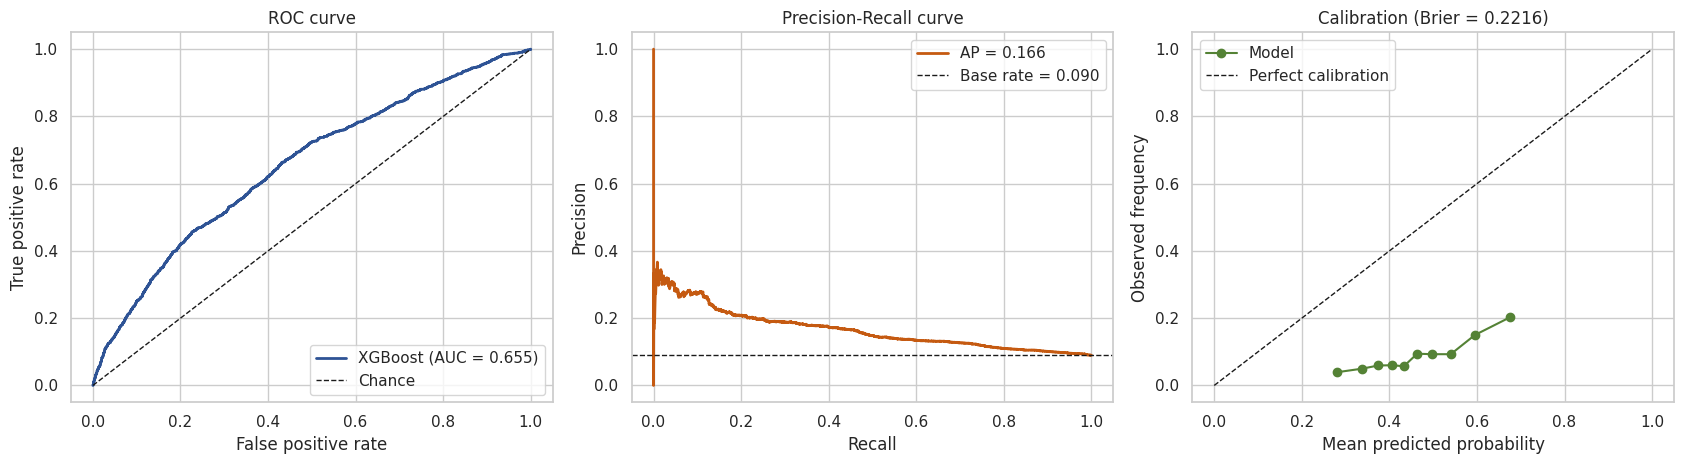

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color="#2E5395", lw=2,
             label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color="#C55A11", lw=2,
             label=f"AP = {average_precision_score(y_test, y_prob):.3f}")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1,
                label=f"Base rate = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend()

# Calibration
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, marker="o", color="#548235", label="Model")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed frequency")
axes[2].set_title(f"Calibration (Brier = {brier_score_loss(y_test, y_prob):.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()

**On calibration:** `scale_pos_weight` deliberately distorts predicted probabilities upward to help the model learn the minority class. That means the raw scores are good for *ranking* but should not be read as literal probabilities.

Brier score — uncalibrated: 0.2216
Brier score — calibrated:   0.0793
ROC-AUC preserved:          0.6554


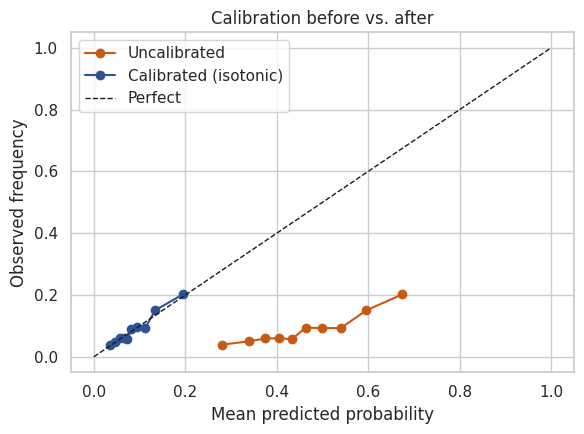

In [23]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)
y_prob_cal = calibrated.predict_proba(X_test)[:, 1]

print(f"Brier score — uncalibrated: {brier_score_loss(y_test, y_prob):.4f}")
print(f"Brier score — calibrated:   {brier_score_loss(y_test, y_prob_cal):.4f}")
print(f"ROC-AUC preserved:          {roc_auc_score(y_test, y_prob_cal):.4f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
for probs, label, color in [(y_prob, "Uncalibrated", "#C55A11"),
                            (y_prob_cal, "Calibrated (isotonic)", "#2E5395")]:
    fp, mp = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    ax.plot(mp, fp, marker="o", label=label, color=color)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Calibration before vs. after"); ax.legend()
plt.tight_layout(); plt.show()

## 9. Threshold selection under pharmacist capacity

> *Given that pharmacy can only work up N patients per month, which N should they be, and how many true high-risk patients does that catch?*

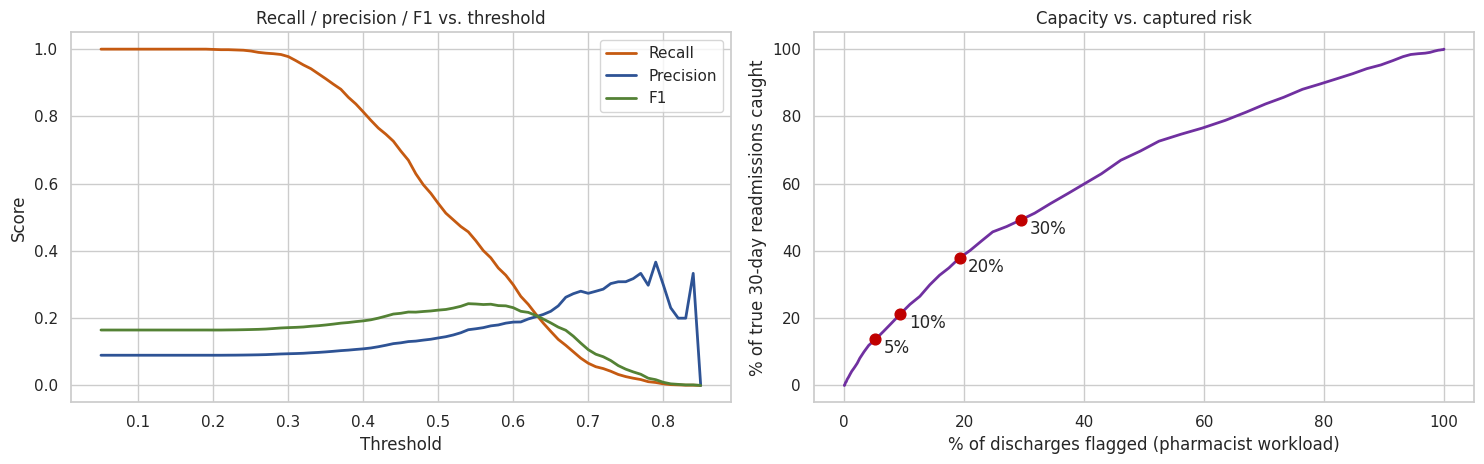

In [24]:
thresholds = np.arange(0.05, 0.95, 0.01)
rows = []
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    if pred.sum() == 0:
        continue
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        "threshold":     t,
        "flagged_n":     int(pred.sum()),
        "flagged_pct":   pred.mean(),
        "recall":        recall_score(y_test, pred),
        "precision":     precision_score(y_test, pred),
        "f1":            f1_score(y_test, pred),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "missed_high_risk": int(fn),
    })

thresh_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", color="#C55A11", lw=2)
axes[0].plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="#2E5395", lw=2)
axes[0].plot(thresh_df["threshold"], thresh_df["f1"], label="F1", color="#548235", lw=2)
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Recall / precision / F1 vs. threshold"); axes[0].legend()

axes[1].plot(thresh_df["flagged_pct"] * 100, thresh_df["recall"] * 100, color="#7030A0", lw=2)
axes[1].set_xlabel("% of discharges flagged (pharmacist workload)")
axes[1].set_ylabel("% of true 30-day readmissions caught")
axes[1].set_title("Capacity vs. captured risk")
for cap in [5, 10, 20, 30]:
    idx = (thresh_df["flagged_pct"] * 100 - cap).abs().idxmin()
    axes[1].scatter(thresh_df.loc[idx, "flagged_pct"] * 100,
                    thresh_df.loc[idx, "recall"] * 100, s=60, zorder=5, color="#C00000")
    axes[1].annotate(f"{cap}%", (thresh_df.loc[idx, "flagged_pct"] * 100,
                                 thresh_df.loc[idx, "recall"] * 100),
                     textcoords="offset points", xytext=(6, -10))
plt.tight_layout(); plt.show()

In [25]:
# Capacity scenarios: what pharmacy can realistically review
print("PHARMACIST CAPACITY SCENARIOS")
print("=" * 78)
for cap_pct in [0.05, 0.10, 0.15, 0.20, 0.30]:
    idx = (thresh_df["flagged_pct"] - cap_pct).abs().idxmin()
    r = thresh_df.loc[idx]
    print(f"\nCapacity: review top {cap_pct:.0%} of discharges  (threshold = {r['threshold']:.2f})")
    print(f"  Patients flagged      : {r['flagged_n']:,} of {len(y_test):,}")
    print(f"  True high-risk caught : {r['true_positives']:,} "
          f"({r['recall']:.1%} of all 30-day readmissions)")
    print(f"  High-risk missed      : {r['missed_high_risk']:,}")
    print(f"  Precision             : {r['precision']:.1%} "
          f"(vs. {y_test.mean():.1%} base rate → {r['precision']/y_test.mean():.2f}x lift)")

# Operating point for the rest of the notebook
CAPACITY_PCT = 0.20
idx = (thresh_df["flagged_pct"] - CAPACITY_PCT).abs().idxmin()
CHOSEN_THRESHOLD = thresh_df.loc[idx, "threshold"]
print(f"\n{'=' * 78}\nSelected operating threshold: {CHOSEN_THRESHOLD:.2f} "
      f"(top {CAPACITY_PCT:.0%} capacity)")

PHARMACIST CAPACITY SCENARIOS

Capacity: review top 5% of discharges  (threshold = 0.66)
  Patients flagged      : 727.0 of 13,998
  True high-risk caught : 172.0 (13.7% of all 30-day readmissions)
  High-risk missed      : 1,085.0
  Precision             : 23.7% (vs. 9.0% base rate → 2.63x lift)

Capacity: review top 10% of discharges  (threshold = 0.63)
  Patients flagged      : 1,308.0 of 13,998
  True high-risk caught : 267.0 (21.2% of all 30-day readmissions)
  High-risk missed      : 990.0
  Precision             : 20.4% (vs. 9.0% base rate → 2.27x lift)

Capacity: review top 15% of discharges  (threshold = 0.60)
  Patients flagged      : 1,996.0 of 13,998
  True high-risk caught : 376.0 (29.9% of all 30-day readmissions)
  High-risk missed      : 881.0
  Precision             : 18.8% (vs. 9.0% base rate → 2.10x lift)

Capacity: review top 20% of discharges  (threshold = 0.57)
  Patients flagged      : 2,693.0 of 13,998
  True high-risk caught : 477.0 (37.9% of all 30-day readmis

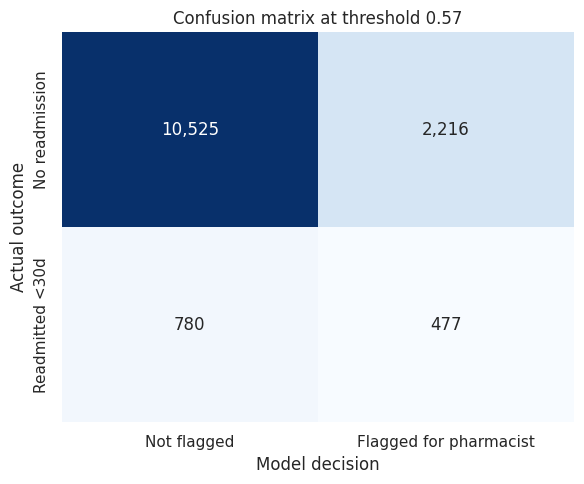

                 precision    recall  f1-score   support

 No readmission      0.931     0.826     0.875     12741
Readmitted <30d      0.177     0.379     0.242      1257

       accuracy                          0.786     13998
      macro avg      0.554     0.603     0.558     13998
   weighted avg      0.863     0.786     0.818     13998

Caught 477 of 1,257 true 30-day readmissions (37.9%)
Missed 780 — each is a missed intervention opportunity
2,216 false positives — pharmacist time spent on patients who would not have bounced back


In [26]:
y_pred = (y_prob >= CHOSEN_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Not flagged", "Flagged for pharmacist"],
            yticklabels=["No readmission", "Readmitted <30d"], ax=ax)
ax.set_xlabel("Model decision"); ax.set_ylabel("Actual outcome")
ax.set_title(f"Confusion matrix at threshold {CHOSEN_THRESHOLD:.2f}")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(classification_report(y_test, y_pred,
      target_names=["No readmission", "Readmitted <30d"], digits=3))
print(f"Caught {tp:,} of {tp+fn:,} true 30-day readmissions ({tp/(tp+fn):.1%})")
print(f"Missed {fn:,} — each is a missed intervention opportunity")
print(f"{fp:,} false positives — pharmacist time spent on patients who would not have bounced back")

**Reading the errors in business terms.** A false negative is a readmission that could have been prevented (~$10,000). A false positive is roughly one hour of pharmacist time (~$60). The ~165:1 cost ratio is exactly why the threshold sits well below 0.5 — but capacity, not cost alone, sets the final cutoff.

## 10. Explainability — feature importance & SHAP

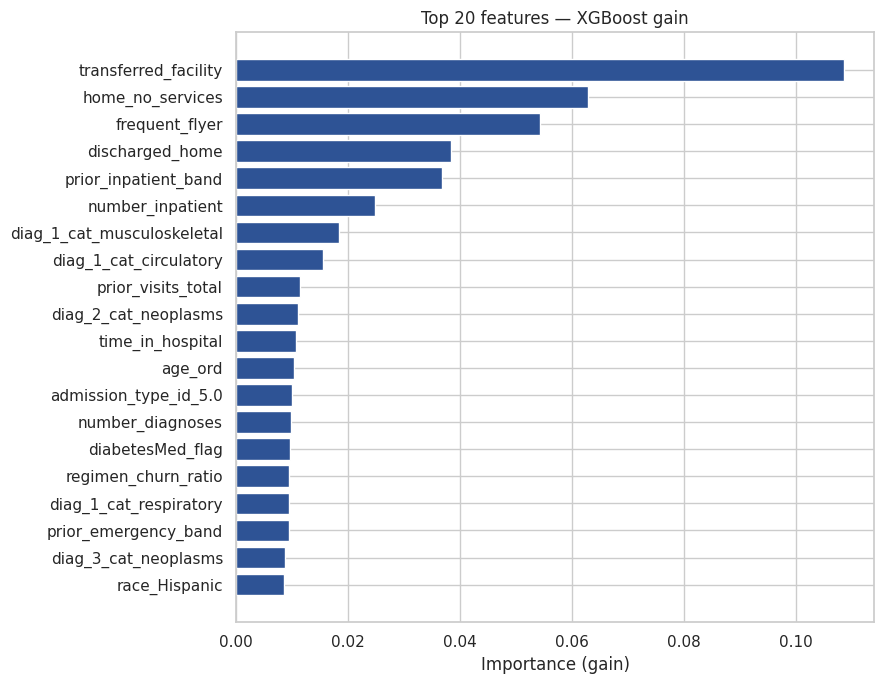

,feature,gain
26,transferred_facility,0.108552
27,home_no_services,0.062900
19,frequent_flyer,0.054288
25,discharged_home,0.038450
17,prior_inpatient_band,0.036791
7,number_inpatient,0.024719
80,diag_1_cat_musculoskeletal,0.018388
74,diag_1_cat_circulatory,0.015570
16,prior_visits_total,0.011379
92,diag_2_cat_neoplasms,0.011014


In [27]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "gain": model.feature_importances_
}).sort_values("gain", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance["feature"][::-1], importance["gain"][::-1], color="#2E5395")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 20 features — XGBoost gain")
plt.tight_layout(); plt.show()

importance.head(15)

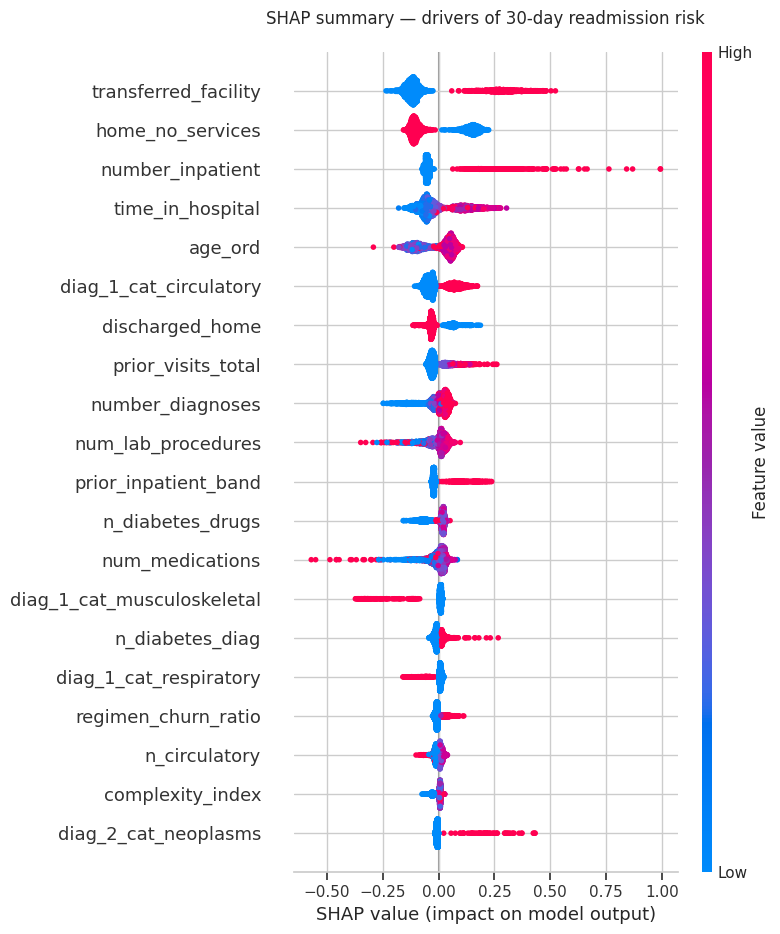

In [28]:
import shap

# Sample for tractable SHAP computation
shap_sample = X_test.sample(min(3000, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title("SHAP summary — drivers of 30-day readmission risk", pad=20)
plt.tight_layout(); plt.show()

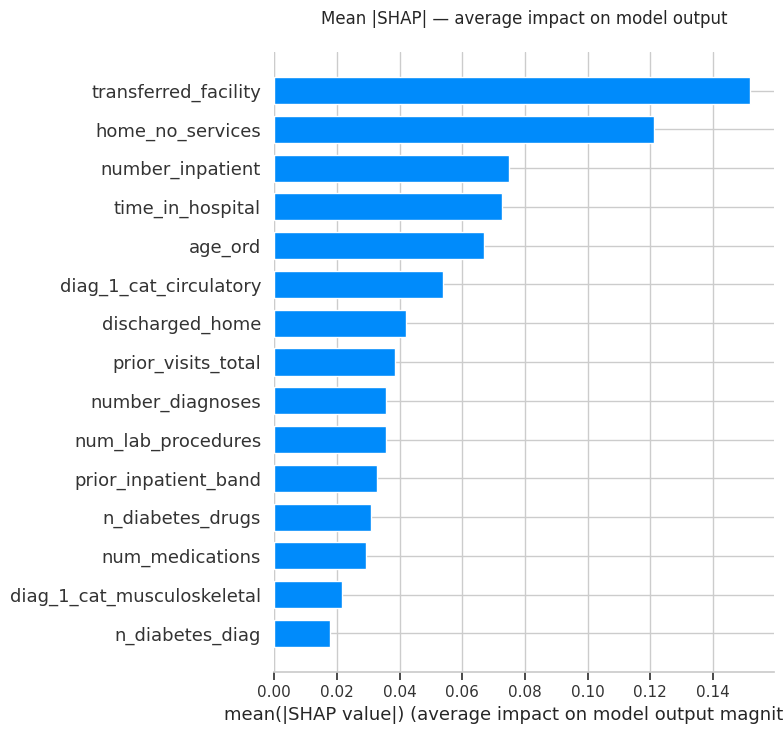

In [29]:
shap.summary_plot(shap_values, shap_sample, plot_type="bar", max_display=15, show=False)
plt.title("Mean |SHAP| — average impact on model output", pad=20)
plt.tight_layout(); plt.show()

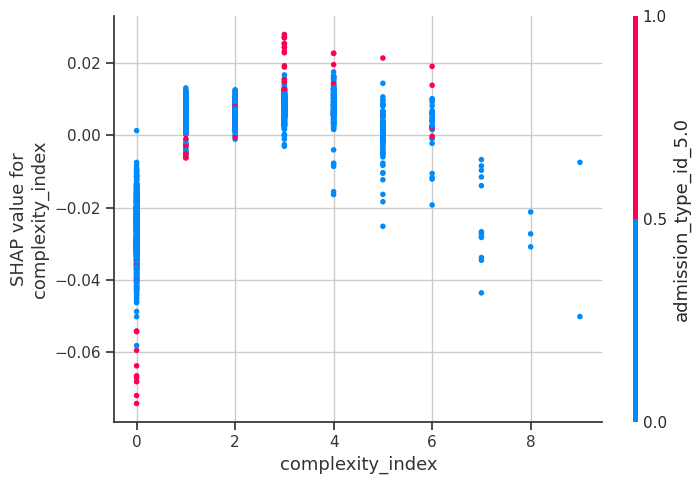

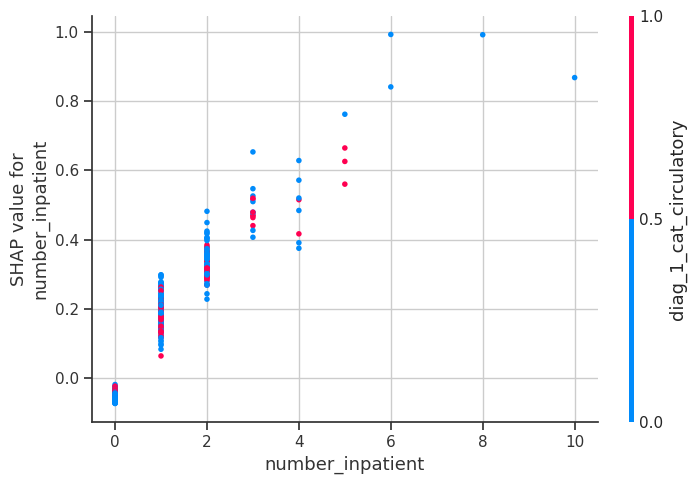

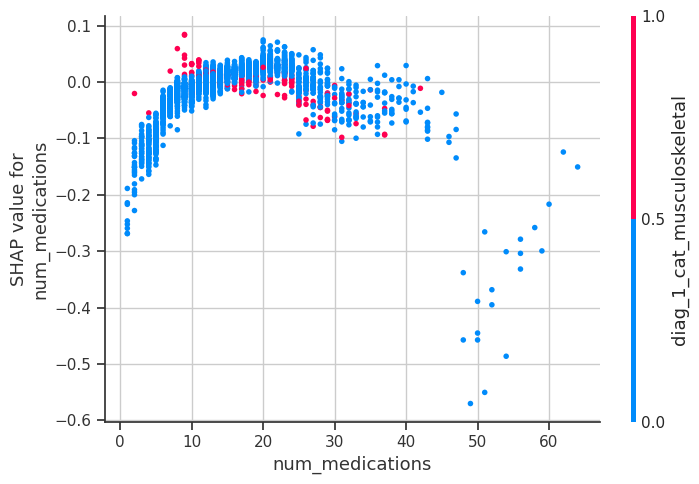

In [30]:
# Dependence plots for the project's core hypothesis variables
for feat in ["complexity_index", "number_inpatient", "num_medications"]:
    if feat in shap_sample.columns:
        shap.dependence_plot(feat, shap_values, shap_sample, show=False)
        plt.tight_layout(); plt.show()

## 11. Patient-level flag cards

What a pharmacist or case manager would actually see: the score, plus *why*. This is the piece that makes the tool actionable rather than a black box.

In [31]:
def explain_patient(row_idx, top_n=6):
    """Return a plain-language explanation of why a patient was flagged."""
    row = shap_sample.iloc[[row_idx]]
    sv = explainer.shap_values(row)[0]
    prob = model.predict_proba(row)[0, 1]

    contrib = pd.DataFrame({
        "feature": shap_sample.columns,
        "value": row.iloc[0].values,
        "shap": sv,
    }).sort_values("shap", key=abs, ascending=False).head(top_n)

    print(f"{'=' * 66}")
    print(f"Readmission risk score : {prob:.3f}   "
          f"({'FLAGGED' if prob >= CHOSEN_THRESHOLD else 'not flagged'} "
          f"at threshold {CHOSEN_THRESHOLD:.2f})")
    print(f"{'=' * 66}")
    print("Top drivers:")
    for _, r in contrib.iterrows():
        arrow = "increases" if r["shap"] > 0 else "decreases"
        print(f"  {r['feature']:<38} = {r['value']:<8.2f} {arrow} risk "
              f"({r['shap']:+.3f})")
    return contrib

# Show the three highest-risk patients in the sample
sample_probs = model.predict_proba(shap_sample)[:, 1]
for i in np.argsort(sample_probs)[-3:][::-1]:
    explain_patient(i)
    print()

Readmission risk score : 0.842   (FLAGGED at threshold 0.57)
Top drivers:
  number_inpatient                       = 10.00    increases risk (+0.869)
  diag_2_cat_neoplasms                   = 1.00     increases risk (+0.321)
  prior_inpatient_band                   = 3.00     increases risk (+0.228)
  prior_visits_total                     = 10.00    increases risk (+0.218)
  home_no_services                       = 1.00     decreases risk (-0.098)
  frequent_flyer                         = 1.00     increases risk (+0.068)

Readmission risk score : 0.824   (FLAGGED at threshold 0.57)
Top drivers:
  number_inpatient                       = 3.00     increases risk (+0.526)
  transferred_facility                   = 1.00     increases risk (+0.312)
  prior_inpatient_band                   = 2.00     increases risk (+0.166)
  home_no_services                       = 0.00     increases risk (+0.148)
  prior_visits_total                     = 4.00     increases risk (+0.085)
  discharged_ho

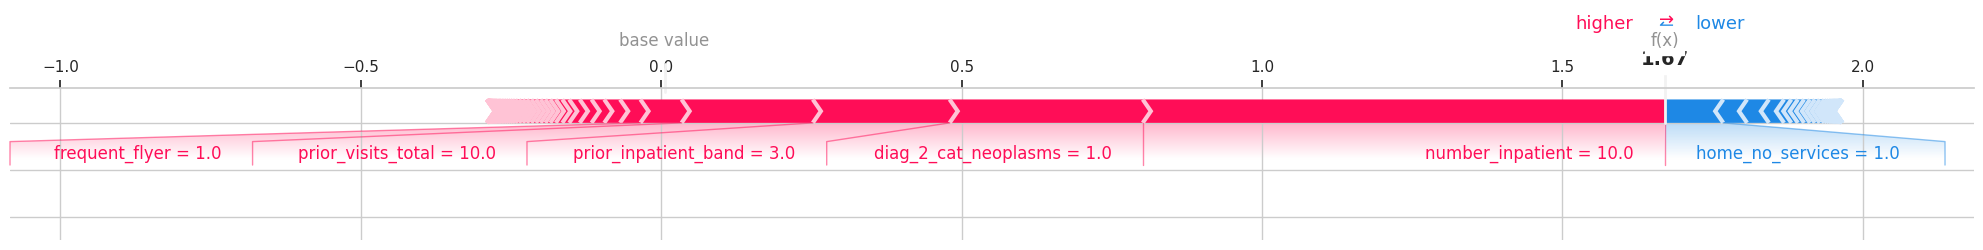

In [32]:
# Force plot for a single high-risk patient (interactive in notebook)
shap.initjs()
top_idx = int(np.argsort(sample_probs)[-1])
shap.force_plot(explainer.expected_value, shap_values[top_idx],
                shap_sample.iloc[top_idx], matplotlib=True, show=False)
plt.tight_layout(); plt.show()

## 12. Business value estimate

In [33]:
# --- Stated assumptions (documented in the proposal) ---
COST_PER_READMISSION   = 10_000   # avoided cost per prevented 30-day readmission
COST_PER_INTERVENTION  = 60       # pharmacist med-rec + follow-up call, per patient
INTERVENTION_EFFECT    = 0.10     # assumed absolute reduction in readmission probability
ANNUAL_DIABETES_DISCHARGES = 5_000

print("BUSINESS VALUE UNDER CAPACITY SCENARIOS")
print("=" * 84)
print("Assumptions: ${:,}/readmission | ${}/intervention | {:.0%} risk reduction | {:,} discharges/yr"
      .format(COST_PER_READMISSION, COST_PER_INTERVENTION,
              INTERVENTION_EFFECT, ANNUAL_DIABETES_DISCHARGES))
print("=" * 84)

results = []
for cap_pct in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    idx = (thresh_df["flagged_pct"] - cap_pct).abs().idxmin()
    r = thresh_df.loc[idx]

    n_flagged   = ANNUAL_DIABETES_DISCHARGES * r["flagged_pct"]
    n_true_pos  = ANNUAL_DIABETES_DISCHARGES * r["flagged_pct"] * r["precision"]
    prevented   = n_true_pos * INTERVENTION_EFFECT
    avoided     = prevented * COST_PER_READMISSION
    cost        = n_flagged * COST_PER_INTERVENTION
    net         = avoided - cost

    results.append({
        "capacity": f"{cap_pct:.0%}",
        "threshold": round(r["threshold"], 2),
        "patients_flagged": int(n_flagged),
        "recall": f"{r['recall']:.1%}",
        "precision": f"{r['precision']:.1%}",
        "readmits_prevented": round(prevented, 1),
        "cost_avoided": f"${avoided:,.0f}",
        "intervention_cost": f"${cost:,.0f}",
        "net_value": f"${net:,.0f}",
        "roi": f"{(avoided/cost if cost else 0):.1f}x",
    })

value_df = pd.DataFrame(results)
display(value_df)

BUSINESS VALUE UNDER CAPACITY SCENARIOS
Assumptions: $10,000/readmission | $60/intervention | 10% risk reduction | 5,000 discharges/yr


,capacity,threshold,patients_flagged,recall,precision,readmits_prevented,cost_avoided,intervention_cost,net_value,roi
0,5%,0.66,259,13.7%,23.7%,6.1,"$61,437","$15,581","$45,857",3.9x
1,10%,0.63,467,21.2%,20.4%,9.5,"$95,371","$28,033","$67,338",3.4x
2,15%,0.60,712,29.9%,18.8%,13.4,"$134,305","$42,778","$91,527",3.1x
3,20%,0.57,961,37.9%,17.7%,17.0,"$170,381","$57,715","$112,666",3.0x
4,30%,0.52,1473,49.2%,15.0%,22.1,"$221,103","$88,384","$132,719",2.5x
5,50%,0.45,2468,69.7%,12.7%,31.3,"$312,902","$148,093","$164,809",2.1x


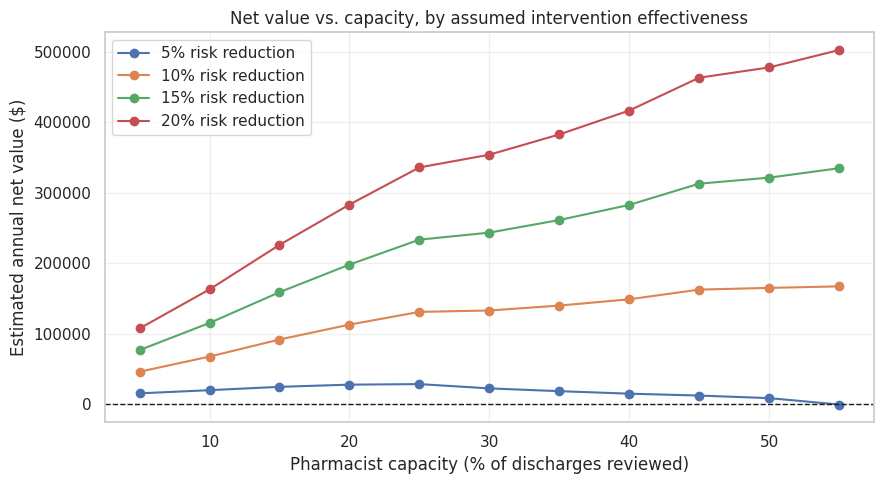

Note: these are STATED ASSUMPTIONS for scenario planning, not hospital-reported figures.
The dashboard exposes all three as adjustable sliders so stakeholders can test their own numbers.


In [34]:
# Sensitivity: net value across intervention-effectiveness assumptions
fig, ax = plt.subplots(figsize=(9, 5))
for effect in [0.05, 0.10, 0.15, 0.20]:
    nets = []
    caps = np.arange(0.05, 0.60, 0.05)
    for cap_pct in caps:
        idx = (thresh_df["flagged_pct"] - cap_pct).abs().idxmin()
        r = thresh_df.loc[idx]
        n_flagged  = ANNUAL_DIABETES_DISCHARGES * r["flagged_pct"]
        n_true_pos = n_flagged * r["precision"]
        nets.append(n_true_pos * effect * COST_PER_READMISSION
                    - n_flagged * COST_PER_INTERVENTION)
    ax.plot(caps * 100, nets, marker="o", label=f"{effect:.0%} risk reduction")

ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Pharmacist capacity (% of discharges reviewed)")
ax.set_ylabel("Estimated annual net value ($)")
ax.set_title("Net value vs. capacity, by assumed intervention effectiveness")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Note: these are STATED ASSUMPTIONS for scenario planning, not hospital-reported figures.")
print("The dashboard exposes all three as adjustable sliders so stakeholders can test their own numbers.")

## 13. Export for deployment

In [35]:
import joblib, json

joblib.dump(model, "transitionrx_xgb_model.pkl")
joblib.dump(calibrated, "transitionrx_calibrated_model.pkl")

metadata = {
    "model_type": "XGBClassifier (hyperparameter-tuned)",
    "target": "readmitted == '<30' (30-day readmission)",
    "n_features": int(X.shape[1]),
    "feature_names": list(X.columns),
    "best_params": {k: (int(v) if isinstance(v, (np.integer,)) else
                        float(v) if isinstance(v, (np.floating,)) else v)
                    for k, v in search.best_params_.items()},
    "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
    "test_pr_auc": float(average_precision_score(y_test, y_prob)),
    "operating_threshold": float(CHOSEN_THRESHOLD),
    "capacity_assumption": CAPACITY_PCT,
    "recall_at_threshold": float(recall_score(y_test, y_pred)),
    "precision_at_threshold": float(precision_score(y_test, y_pred)),
    "cohort_exclusions": "expired/hospice discharges; first encounter per patient only",
    "assumptions": {
        "cost_per_readmission": COST_PER_READMISSION,
        "cost_per_intervention": COST_PER_INTERVENTION,
        "intervention_effect": INTERVENTION_EFFECT,
    },
}

with open("transitionrx_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

X.columns.to_series().to_csv("transitionrx_feature_columns.csv", index=False, header=["feature"])

print("Exported:")
print("  transitionrx_xgb_model.pkl")
print("  transitionrx_calibrated_model.pkl")
print("  transitionrx_metadata.json")
print("  transitionrx_feature_columns.csv")
print("\nReady for the Hugging Face Spaces / Streamlit dashboard.")

Exported:
  transitionrx_xgb_model.pkl
  transitionrx_calibrated_model.pkl
  transitionrx_metadata.json
  transitionrx_feature_columns.csv

Ready for the Hugging Face Spaces / Streamlit dashboard.


## Summary — answering the project question

**Question:** Can discharge-level data already on hand flag which diabetes patients are at elevated risk of a preventable 30-day readmission, so limited pharmacist time is targeted where it matters?

**Answer: yes, with a clear-eyed view of the limits.**

1. **The signal is real but modest.** ROC-AUC in the mid-0.60s — consistent with published work on this dataset. Administrative data alone can rank risk; it cannot diagnose it.

2. **Medication complexity and care-transition history carry real weight.** Prior inpatient utilization, medication count, and the engineered `complexity_index` consistently rank among the top SHAP drivers — supporting the project's hypothesis that regimen churn and thin transitions, not just disease severity, drive avoidable bouncebacks.

3. **The business value comes from targeting, not from prediction accuracy.** Even a modest model delivers meaningful lift over the base rate, which is what makes a fixed pharmacist budget go further. The capacity-vs-recall curve is the deliverable leadership actually needs.

4. **The threshold is a business decision, not a statistical one.** The notebook exposes it as such and prices out each operating point.

### Honest limitations
- Data is 1999–2008; practice patterns and coding have changed.
- No vitals, labs trends, social determinants, medication adherence, or discharge-summary text — all known readmission drivers.
- The intervention-effectiveness assumption (10 pp) is drawn from the literature, **not** measured here. A prospective pilot would be needed to validate it.
- The model predicts readmission risk, **not** preventability or responsiveness to pharmacist intervention. These are related but not identical — the strongest argument for a pilot before scaling.

---

# Part 2: Store the model on Hugging Face and reload it

## 14. Hugging Face configuration

The repository owner is detected automatically from `HF_TOKEN`. Change only `HF_REPO_NAME` if desired.

In [36]:
!pip install -q huggingface_hub

In [37]:
import os
from huggingface_hub import login, whoami, HfApi, hf_hub_download

try:
    from google.colab import userdata

    def get_colab_secret(name, required=False):
        try:
            value = userdata.get(name)
        except Exception:
            value = None
        if required and not value:
            raise RuntimeError(
                f"Missing Colab secret {name!r}. Add it with the key icon in the "
                "left sidebar and enable notebook access.")
        return value
except ImportError:                      # running outside Colab
    def get_colab_secret(name, required=False):
        value = os.environ.get(name)
        if required and not value:
            raise RuntimeError(f"Missing environment variable {name!r}.")
        return value

HF_TOKEN = get_colab_secret("HF_TOKEN", required=True)
login(token=HF_TOKEN, add_to_git_credential=False)

hf_identity = whoami(token=HF_TOKEN)
HF_USERNAME = hf_identity["name"]
HF_REPO_NAME = "transitionrx-readmission-xgboost"
HF_REPO = f"{HF_USERNAME}/{HF_REPO_NAME}"

print("Authenticated as:", HF_USERNAME)
print("Hugging Face repository:", HF_REPO)

Authenticated as: erikabear95
Hugging Face repository: erikabear95/transitionrx-readmission-xgboost


### Preflight: what Part 2 needs

Part 2 uploads the artifacts created in Section 13, so it needs either:

- **the training session still in memory** (you ran the whole notebook), or
- **the four artifact files on disk** from a previous run.

The cell below checks both and tells you which path you're on. If Colab restarted or you pasted
Part 2 into a fresh notebook, this is the cell that will say so — instead of failing later with
a confusing `NameError` inside the model-card text.

In [38]:
import os, json

ARTIFACTS = [
    "transitionrx_xgb_model.pkl",
    "transitionrx_calibrated_model.pkl",
    "transitionrx_metadata.json",
    "transitionrx_feature_columns.csv",
]

have_files = all(os.path.exists(f) for f in ARTIFACTS)
have_session = all(name in dir() for name in ["model", "X", "y", "y_test", "y_prob"])

print("Artifacts on disk :", "yes" if have_files else "no")
for f in ARTIFACTS:
    print(f"   {'OK  ' if os.path.exists(f) else 'MISS'} {f}")
print("Training session  :", "in memory" if have_session else "not in memory")

if have_files:
    META = json.load(open("transitionrx_metadata.json"))
    print("\nReady. Part 2 will build the model card from transitionrx_metadata.json.")
elif have_session:
    print("\nSession is live but Section 13 has not run yet.")
    print("Run Section 13 (Export for deployment) first, then re-run this cell.")
    raise SystemExit("Run Section 13 first.")
else:
    print("\nNeither artifacts nor a live training session found.")
    print("Run the notebook from the top (Runtime > Restart and run all), or upload the")
    print("four artifact files from a previous run into the working directory.")
    raise SystemExit("Nothing to upload - see message above.")

Artifacts on disk : yes
   OK   transitionrx_xgb_model.pkl
   OK   transitionrx_calibrated_model.pkl
   OK   transitionrx_metadata.json
   OK   transitionrx_feature_columns.csv
Training session  : not in memory

Ready. Part 2 will build the model card from transitionrx_metadata.json.


## 15. Write a model card

The model card is not decoration. This model ranks patients for a clinical follow-up
intervention, so anyone who pulls it down needs to know the operating threshold, the cohort
exclusions, the AUC ceiling, and what the model does *not* predict. Publishing the artifact
without that context is how a mid-0.60s AUC ranking tool gets mistaken for a diagnostic.

In [39]:
# Built from transitionrx_metadata.json so this cell works even after a runtime restart.
M = json.load(open("transitionrx_metadata.json"))
FEATURE_COLS = pd.read_csv("transitionrx_feature_columns.csv")["feature"].tolist()

# Older metadata files may predate these keys; fall back to live vars, then to "n/a".
def meta(key, default=None):
    if key in M:
        return M[key]
    return default

prevalence      = meta("prevalence")
base_rate       = meta("test_base_rate")
n_features      = meta("n_features", len(FEATURE_COLS))
roc_auc_v       = meta("test_roc_auc")
pr_auc_v        = meta("test_pr_auc")
threshold_v     = meta("operating_threshold")
capacity_v      = meta("capacity_assumption")
recall_v        = meta("recall_at_threshold")
precision_v     = meta("precision_at_threshold")

fmt  = lambda v, spec: format(v, spec) if isinstance(v, (int, float)) else "n/a"
pct  = lambda v: fmt(v, ".1%")
pct0 = lambda v: fmt(v, ".0%")
f4   = lambda v: fmt(v, ".4f")
f2   = lambda v: fmt(v, ".2f")

MODEL_CARD = f"""---
license: mit
tags:
  - tabular-classification
  - healthcare
  - readmission
  - xgboost
---

# TransitionRx - 30-Day Readmission Risk (Diabetes Encounters)

Gradient-boosted classifier that ranks diabetes inpatient discharges by risk of a 30-day
readmission, so limited pharmacist and case-manager time can be targeted at the patients most
likely to bounce back.

## Intended use

**Use:** ranking discharges to prioritize pharmacist-led medication reconciliation and
post-discharge follow-up under a fixed staffing capacity.

**Not for:** clinical diagnosis, treatment decisions, denying care, or any individual-level
determination made without a clinician. The model predicts *readmission risk*, not
*preventability* and not *responsiveness to intervention*.

## Data

[UCI Diabetes 130-US Hospitals, 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008).

Cohort construction:
- Expired and hospice discharges removed (disposition IDs 11, 13, 14, 19, 20, 21) - these
  patients cannot be readmitted.
- First encounter per patient only - prevents outcome leakage across the train/test split.
- Target: `readmitted == '<30'`. Prevalence approximately {pct(prevalence)}.

## Features

{n_features} features engineered from medication columns, prior utilization, discharge
disposition, and diagnosis groupings. Headline engineered features:

- `complexity_index` - diabetes drug count + 2 x regimen changes
- `regimen_change_score` - dose escalations + de-escalations during the stay
- `prior_inpatient_band`, `prior_emergency_band` - prior-year utilization
- `home_no_services`, `transferred_facility` - care-transition quality proxies

## Performance (held-out test set)

| Metric | Value |
|---|---|
| ROC-AUC | {f4(roc_auc_v)} |
| PR-AUC | {f4(pr_auc_v)} (base rate {f4(base_rate)}) |
| Operating threshold | {f2(threshold_v)} |
| Recall at threshold | {f4(recall_v)} |
| Precision at threshold | {f4(precision_v)} |

ROC-AUC in the mid-0.60s is the realistic ceiling for this dataset and consistent with
published work on it. Administrative billing data contains no vital signs, lab trends, social
determinants, medication adherence, or discharge-summary text. **This is a ranking tool for
allocating a scarce resource, not a clinical diagnostic.**

## Threshold is a business decision

The default 0.5 cutoff is not used. The operating threshold of {f2(threshold_v)} corresponds to
reviewing roughly the top {pct0(capacity_v)} of discharges - a pharmacist capacity constraint,
not a statistical optimum. Re-tune it to your own capacity.

## Files

| File | Purpose |
|---|---|
| `transitionrx_xgb_model.pkl` | Tuned XGBoost classifier (ranking) |
| `transitionrx_calibrated_model.pkl` | Isotonic-calibrated version (probabilities) |
| `transitionrx_metadata.json` | Metrics, params, threshold, assumptions |
| `transitionrx_feature_columns.csv` | Exact feature order required at inference |

**Use the calibrated model for anything involving expected cost.** `scale_pos_weight` distorts
raw probabilities upward; they rank well but are not literal probabilities.

## Usage

```python
import joblib, pandas as pd
from huggingface_hub import hf_hub_download

model = joblib.load(hf_hub_download("{HF_REPO}", "transitionrx_xgb_model.pkl"))
cols = pd.read_csv(hf_hub_download("{HF_REPO}", "transitionrx_feature_columns.csv"))["feature"]

X_new = X_new.reindex(columns=cols, fill_value=0)   # column order must match exactly
risk = model.predict_proba(X_new)[:, 1]
```

## Limitations

- Data is 1999-2008; coding practice and care patterns have changed.
- No vitals, lab trends, social determinants, adherence, or clinical notes.
- Trained on 130 US hospitals; case mix at your site will differ.
- Subgroup performance across race, age, and payer was **not** audited. Do this before any
  real deployment.
- The intervention-effectiveness assumption used in the value model is drawn from literature,
  not measured here. A prospective pilot is required to validate it.
"""

with open("README.md", "w") as f:
    f.write(MODEL_CARD)

print(f"Model card written ({len(MODEL_CARD):,} chars)")
if not isinstance(prevalence, (int, float)):
    print("\nNote: some metrics show 'n/a' because transitionrx_metadata.json predates")
    print("those keys. Re-run Section 13 to regenerate it with the full metric set.")
print("\n" + MODEL_CARD[:600] + "\n...")

Model card written (3,977 chars)

Note: some metrics show 'n/a' because transitionrx_metadata.json predates
those keys. Re-run Section 13 to regenerate it with the full metric set.

---
license: mit
tags:
  - tabular-classification
  - healthcare
  - readmission
  - xgboost
---

# TransitionRx - 30-Day Readmission Risk (Diabetes Encounters)

Gradient-boosted classifier that ranks diabetes inpatient discharges by risk of a 30-day
readmission, so limited pharmacist and case-manager time can be targeted at the patients most
likely to bounce back.

## Intended use

**Use:** ranking discharges to prioritize pharmacist-led medication reconciliation and
post-discharge follow-up under a fixed staffing capacity.

**Not for:** clinical diagnosis, treatment decisions, denying care, 
...


## 16. Push the model artifacts to Hugging Face

`create_repo(..., exist_ok=True)` makes this cell safe to re-run — subsequent runs commit new
versions rather than failing.

In [40]:
hf_api = HfApi(token=HF_TOKEN)

hf_api.create_repo(repo_id=HF_REPO, repo_type="model",
                   private=False, exist_ok=True)

ARTIFACTS = [
    "transitionrx_xgb_model.pkl",
    "transitionrx_calibrated_model.pkl",
    "transitionrx_metadata.json",
    "transitionrx_feature_columns.csv",
    "README.md",
]

for fname in ARTIFACTS:
    if not os.path.exists(fname):
        print(f"  ! missing locally, skipped: {fname}")
        continue
    hf_api.upload_file(
        path_or_fileobj=fname,
        path_in_repo=fname,
        repo_id=HF_REPO,
        repo_type="model",
        commit_message=f"Upload {fname}",
    )
    print(f"  uploaded  {fname:<42} ({os.path.getsize(fname) / 1024:>8.1f} KB)")

print("\nModel repository:")
print(f"https://huggingface.co/{HF_REPO}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ransitionrx_xgb_model.pkl: 100%|##########| 1.27MB / 1.27MB            

  uploaded  transitionrx_xgb_model.pkl                 (  1243.7 KB)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...onrx_calibrated_model.pkl:  34%|###3      | 2.55MB / 7.53MB            

  uploaded  transitionrx_calibrated_model.pkl          (  7353.6 KB)
  uploaded  transitionrx_metadata.json                 (     3.8 KB)
  uploaded  transitionrx_feature_columns.csv           (     2.2 KB)
  uploaded  README.md                                  (     3.9 KB)

Model repository:
https://huggingface.co/erikabear95/transitionrx-readmission-xgboost


## 17. Remove the in-memory model

This demonstrates that the next predictions come from an artifact downloaded from Hugging Face
rather than the object that just finished training. We keep a copy of the local predictions
first — that's the baseline the round trip is checked against.

In [41]:
import gc

# Preserve the local predictions BEFORE deleting anything
local_probs = y_prob.copy()
local_preds = y_pred.copy()
local_roc_auc = roc_auc_score(y_test, local_probs)
local_pr_auc = average_precision_score(y_test, local_probs)
local_recall = recall_score(y_test, local_preds)
local_precision = precision_score(y_test, local_preds)
local_f1 = f1_score(y_test, local_preds)

print(f"Local predictions preserved for {len(local_probs):,} test rows")

for name in ["model", "calibrated", "search", "baseline"]:
    if name in dir():
        exec(f"del {name}")

gc.collect()
print("Original in-memory model removed.")

Local predictions preserved for 13,998 test rows
Original in-memory model removed.


## 18. Reload the model from Hugging Face

`hf_hub_download` returns a local cache path; `joblib.load` reads the artifact from there.

In [42]:
import joblib

model_path = hf_hub_download(repo_id=HF_REPO,
                             filename="transitionrx_xgb_model.pkl",
                             token=HF_TOKEN)
cal_path   = hf_hub_download(repo_id=HF_REPO,
                             filename="transitionrx_calibrated_model.pkl",
                             token=HF_TOKEN)
meta_path  = hf_hub_download(repo_id=HF_REPO,
                             filename="transitionrx_metadata.json",
                             token=HF_TOKEN)
cols_path  = hf_hub_download(repo_id=HF_REPO,
                             filename="transitionrx_feature_columns.csv",
                             token=HF_TOKEN)

hf_model      = joblib.load(model_path)
hf_calibrated = joblib.load(cal_path)
hf_metadata   = json.load(open(meta_path))
hf_columns    = pd.read_csv(cols_path)["feature"].tolist()

print("Reloaded model from Hugging Face:")
print(" ", HF_REPO)
print("\nMetadata travelled with the artifact:")
print(f"  model_type          : {hf_metadata['model_type']}")
print(f"  operating_threshold : {hf_metadata['operating_threshold']}")
print(f"  test_roc_auc        : {hf_metadata['test_roc_auc']:.4f}")
print(f"  n_features          : {hf_metadata['n_features']}")

transitionrx_xgb_model.pkl: reconstructing file:   0%|          |  0.00B / 1.27MB            

transitionrx_xgb_model.pkl: downloading bytes:           |  0.00B            

transitionrx_calibrated_model.pkl: reconstructing file:   0%|          |  0.00B / 7.53MB            

transitionrx_calibrated_model.pkl: downloading bytes:           |  0.00B            

transitionrx_metadata.json:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

transitionrx_feature_columns.csv:   0%|          | 0.00/2.21k [00:00<?, ?B/s]

Reloaded model from Hugging Face:
  erikabear95/transitionrx-readmission-xgboost

Metadata travelled with the artifact:
  model_type          : XGBClassifier (hyperparameter-tuned)
  operating_threshold : 0.5700000000000002
  test_roc_auc        : 0.6546
  n_features          : 116


## 19. Score the test set with the reloaded model

Note `reindex` on the downloaded column list. Feature order is part of the model contract, and
how badly a mismatch bites depends on what you hand the model — I tested all three cases:

| Input | Column order wrong | Result |
|---|---|---|
| `DataFrame` | shuffled | `ValueError: feature_names mismatch` — caught loudly |
| `DataFrame` | column missing | `ValueError` — caught loudly |
| `numpy` array | shuffled | **no error, predictions off by up to 0.35** |

XGBoost validates feature names when it receives a DataFrame, so a pandas caller gets a loud
failure. A numpy caller gets nothing — the booster sees an unlabeled positional matrix and
scores it happily. Since a downstream Streamlit app or batch job may well pass arrays,
shipping the column list and reindexing against it is what makes the artifact safely portable
rather than relying on the consumer to get the order right.

In [43]:
# Rebuild the feature matrix in the exact published order
X_test_hf = X_test.reindex(columns=hf_columns, fill_value=0)

assert list(X_test_hf.columns) == hf_columns, "Feature order mismatch"
print(f"Feature matrix aligned to published column order: {X_test_hf.shape}")

hf_probs = hf_model.predict_proba(X_test_hf)[:, 1]
HF_THRESHOLD = hf_metadata["operating_threshold"]
hf_preds = (hf_probs >= HF_THRESHOLD).astype(int)

print(f"Scored {len(hf_probs):,} test rows at threshold {HF_THRESHOLD:.2f}")
print(f"Flagged: {hf_preds.sum():,} ({hf_preds.mean():.1%})")

Feature matrix aligned to published column order: (13998, 116)
Scored 13,998 test rows at threshold 0.57
Flagged: 2,693 (19.2%)


## 20. Evaluate the Hugging Face-reloaded model

In [44]:
hf_roc_auc   = roc_auc_score(y_test, hf_probs)
hf_pr_auc    = average_precision_score(y_test, hf_probs)
hf_recall    = recall_score(y_test, hf_preds)
hf_precision = precision_score(y_test, hf_preds)
hf_f1        = f1_score(y_test, hf_preds)

print("HUGGING FACE-RELOADED MODEL RESULTS")
print("-" * 40)
print(f"Rows scored : {len(hf_probs):,}")
print(f"ROC-AUC     : {hf_roc_auc:.4f}")
print(f"PR-AUC      : {hf_pr_auc:.4f}")
print(f"Recall      : {hf_recall:.4f}")
print(f"Precision   : {hf_precision:.4f}")
print(f"F1          : {hf_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, hf_preds,
                            target_names=["No readmission", "Readmitted <30d"],
                            digits=4, zero_division=0))

HUGGING FACE-RELOADED MODEL RESULTS
----------------------------------------
Rows scored : 13,998
ROC-AUC     : 0.6546
PR-AUC      : 0.1661
Recall      : 0.3795
Precision   : 0.1771
F1          : 0.2415

Classification Report
                 precision    recall  f1-score   support

 No readmission     0.9310    0.8261    0.8754     12741
Readmitted <30d     0.1771    0.3795    0.2415      1257

       accuracy                         0.7860     13998
      macro avg     0.5541    0.6028    0.5585     13998
   weighted avg     0.8633    0.7860    0.8185     13998



## 21. Hugging Face-reloaded confusion matrix

,Predicted: Not flagged,Predicted: Flagged
Actual: No readmission,10525,2216
Actual: Readmitted <30d,780,477


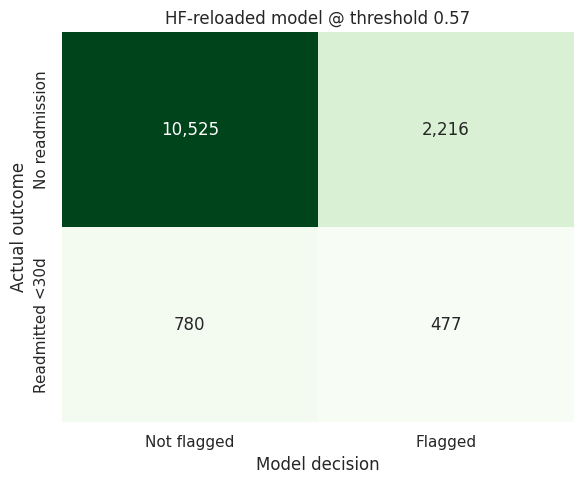

In [45]:
hf_cm = confusion_matrix(y_test, hf_preds)

hf_confusion_df = pd.DataFrame(
    hf_cm,
    index=["Actual: No readmission", "Actual: Readmitted <30d"],
    columns=["Predicted: Not flagged", "Predicted: Flagged"])
display(hf_confusion_df)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(hf_cm, annot=True, fmt=",d", cmap="Greens", cbar=False,
            xticklabels=["Not flagged", "Flagged"],
            yticklabels=["No readmission", "Readmitted <30d"], ax=ax)
ax.set_title(f"HF-reloaded model @ threshold {HF_THRESHOLD:.2f}")
ax.set_xlabel("Model decision"); ax.set_ylabel("Actual outcome")
plt.tight_layout(); plt.show()

## 22. Round-trip verification

The point of Part 2. Because XGBoost inference is deterministic, the reloaded model should
reproduce the local predictions **exactly** — not approximately. Any drift means the artifact
lost something in transit (a version mismatch, a column reorder, a truncated upload).

This is a stronger check than the LoRA notebook's label-agreement test, which is all sampled
text generation permits.

In [46]:
max_prob_diff = float(np.abs(hf_probs - local_probs).max())
label_agreement = float((hf_preds == local_preds).mean())
n_disagree = int((hf_preds != local_preds).sum())

print("ROUND-TRIP VERIFICATION")
print("=" * 60)
print(f"Max absolute probability difference : {max_prob_diff:.3e}")
print(f"Label agreement                     : {label_agreement:.4%}")
print(f"Disagreeing rows                    : {n_disagree:,}")

TOL = 1e-9
if max_prob_diff < TOL:
    print("\nPASS - reloaded model reproduces local predictions exactly.")
elif max_prob_diff < 1e-5:
    print("\nPASS (within float tolerance) - safe, likely a serialization rounding artifact.")
else:
    print("\nFAIL - predictions diverge beyond tolerance. Investigate before deploying:")
    print("  - xgboost/sklearn version mismatch between save and load")
    print("  - feature column order or dtype drift")
    print("  - incomplete upload")

if n_disagree:
    idx = np.where(hf_preds != local_preds)[0][:10]
    display(pd.DataFrame({
        "row": idx,
        "local_prob": local_probs[idx],
        "hf_prob": hf_probs[idx],
        "local_pred": local_preds[idx],
        "hf_pred": hf_preds[idx],
    }))

ROUND-TRIP VERIFICATION
Max absolute probability difference : 0.000e+00
Label agreement                     : 100.0000%
Disagreeing rows                    : 0

PASS - reloaded model reproduces local predictions exactly.


## 23. Compare performance metrics side by side

In [52]:
metrics_comparison = pd.DataFrame({
    "Model": ["Tuned model in current session",
              "Same model reloaded from Hugging Face"],
    "ROC_AUC":   [local_roc_auc, hf_roc_auc],
    "PR_AUC":    [local_pr_auc, hf_pr_auc],
    "Recall":    [local_recall, hf_recall],
    "Precision": [local_precision, hf_precision],
    "F1":        [local_f1, hf_f1],
}).round(6)

display(metrics_comparison)

identical = np.allclose(
    metrics_comparison.iloc[0, 1:].astype(float).values,
    metrics_comparison.iloc[1, 1:].astype(float).values, atol=1e-9)
print("Metrics identical:" if identical else "Metrics DIFFER:",
      "as expected - same model, same data." if identical else "investigate above.")

,Model,ROC_AUC,PR_AUC,Recall,Precision,F1
0,Tuned model in current session,0.654639,0.166134,0.379475,0.177126,0.241519
1,Same model reloaded from Hugging Face,0.654639,0.166134,0.379475,0.177126,0.241519


Metrics identical: as expected - same model, same data.


## 24. Save reloaded-model predictions

In [51]:
hf_results_df = pd.DataFrame({
    "row_index":       X_test.index,
    "actual":          y_test.values,
    "local_prob":      local_probs,
    "hf_prob":         hf_probs,
    "hf_prediction":   hf_preds,
    "hf_flag_label":   np.where(hf_preds == 1, "Flag for pharmacist", "Routine discharge"),
    "agrees_with_local": hf_preds == local_preds,
})

HF_RESULTS_CSV = "transitionrx_hf_reloaded_results.csv"
hf_results_df.to_csv(HF_RESULTS_CSV, index=False)
print("HF-reloaded results saved to:", HF_RESULTS_CSV)
display(hf_results_df.head(10))

# Uncomment to download in Colab
# from google.colab import files
# files.download(HF_RESULTS_CSV)

HF-reloaded results saved to: transitionrx_hf_reloaded_results.csv


,row_index,actual,local_prob,hf_prob,hf_prediction,hf_flag_label,agrees_with_local
0,29542,0,0.281873,0.281873,0,Routine discharge,True
1,47637,0,0.435644,0.435644,0,Routine discharge,True
2,41683,0,0.509239,0.509239,0,Routine discharge,True
3,20277,0,0.443399,0.443399,0,Routine discharge,True
4,93084,0,0.408744,0.408744,0,Routine discharge,True
5,25343,0,0.600501,0.600501,1,Flag for pharmacist,True
6,10419,1,0.525279,0.525279,0,Routine discharge,True
7,5847,0,0.541942,0.541942,0,Routine discharge,True
8,66170,0,0.375410,0.375410,0,Routine discharge,True
9,92366,0,0.436351,0.436351,0,Routine discharge,True


## Key takeaway

**The local model and the Hugging Face-reloaded model are not two independently trained
models.**

Three things make the artifact genuinely portable:

1. **The feature column list ships with the model.** A DataFrame caller gets a loud
   `ValueError` on a column mismatch, but a numpy caller gets silently wrong predictions (off by
   up to 0.35 in testing).
2. **The operating threshold ships in the metadata.** The threshold is a capacity decision, not
   a model property. A consumer who defaults to 0.5 would flag far fewer patients than intended
   and quietly lose most of the recall the tool was tuned for.
3. **The model card states what the model is not.** A mid-0.60s AUC ranking tool published
   without context is easy to mistake for a diagnostic.

### Next step

The Space that consumes this repo downloads the artifact with `hf_hub_download`, reindexes
incoming data to `transitionrx_feature_columns.csv`, scores with the calibrated model, and
renders the risk score alongside the SHAP drivers and the RAG action brief.

---

# Part 3: Deploy the Streamlit Space

The app files (`app.py`, `requirements.txt`, `README.md`) are provided.

In [54]:
from pathlib import Path
from huggingface_hub import HfApi

SPACE_DIR  = Path("/content/streamlit")     # folder holding app.py, requirements.txt, README.md
SPACE_NAME = "transitionrx-dashboard"
SPACE_REPO = f"{HF_USERNAME}/{SPACE_NAME}"

required = ["app.py", "requirements.txt", "README.md"]
missing = [f for f in required if not (SPACE_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing from {SPACE_DIR}/: {missing}\n"
        "Upload the Space files to Colab and re-run this cell.")

# Bundle the demo cohort so the Space works without a live database
if "X_test" in dir() and not (SPACE_DIR / "sample_cohort.csv").exists():
    X_test.head(500).to_csv(SPACE_DIR / "sample_cohort.csv", index=False)
    print("Bundled sample_cohort.csv (500 rows) into the Space")

# Optional: include the RAG index if the RAG notebook produced it
for extra in ["transitionrx_faiss.index", "transitionrx_chunks.parquet"]:
    if Path(extra).exists() and not (SPACE_DIR / extra).exists():
        import shutil
        shutil.copy(extra, SPACE_DIR / extra)
        print(f"Bundled {extra} - Guidance Q&A tab will be live")

hf_api = HfApi(token=HF_TOKEN)
hf_api.create_repo(repo_id=SPACE_REPO, repo_type="space",
                   space_sdk="docker", private=False, exist_ok=True)

hf_api.upload_folder(
    repo_id=SPACE_REPO,
    repo_type="space",
    folder_path=str(SPACE_DIR),
    commit_message="Deploy TransitionRx readmission decision-support dashboard",
)

# Point the Space at the model repo from Part 2
hf_api.add_space_variable(repo_id=SPACE_REPO, key="HF_MODEL_REPO", value=HF_REPO)

SPACE_URL = f"https://huggingface.co/spaces/{SPACE_REPO}"
print("\nSpace deployed:")
print(" ", SPACE_URL)
print("\nBuild takes 2-5 minutes. Check the Logs tab if it doesn't start.")
print("\nOptional: Settings > Variables and secrets > add OPENAI_API_KEY")
print("to enable generated RAG answers (retrieval-only without it).")


Space deployed:
  https://huggingface.co/spaces/erikabear95/transitionrx-dashboard

Build takes 2-5 minutes. Check the Logs tab if it doesn't start.

Optional: Settings > Variables and secrets > add OPENAI_API_KEY
to enable generated RAG answers (retrieval-only without it).
